In [1]:
import os
import sys
import requests
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns   
import math
import scipy.stats as stats
from io import StringIO
from datetime import datetime, timedelta
import warnings 
warnings.filterwarnings("ignore")

In [2]:
# 폰트 깨짐 방지
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') 
else:
    
    plt.rc('font', family='NanumGothic')

# 마이너스 기호방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv("clean_data.csv")

In [4]:
df

,t_dat,customer_id,article_id,price,sales_channel_id,prod_name,product_type_name,product_group_name,graphical_appearance_name,colour_group_name,...,index_group_name,section_name,garment_group_name,FN,Active,club_member_status,fashion_news_frequency,age,prediction,age_group
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,29.99,2,Atlanta Push Body Harlow,Underwear body,Underwear,Solid,Black,...,Ladieswear,Womens Lingerie,"Under-, Nightwear",0,0,ACTIVE,NONE,24,0706016001 0706016002 0372860001 0610776002 07...,20대
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,17.99,2,Rae Push (Melbourne) 2p,Bra,Underwear,Solid,Light Pink,...,Ladieswear,Womens Lingerie,"Under-, Nightwear",0,0,ACTIVE,NONE,24,0706016001 0706016002 0372860001 0610776002 07...,20대
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,8.99,2,Inca Jumper,Sweater,Garment Upper body,Melange,Pink,...,Divided,Divided Selected,Knitwear,1,1,ACTIVE,Regularly,32,0706016001 0706016002 0372860001 0610776002 07...,30대
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,9.99,2,W YODA KNIT OL OFFER,Sweater,Garment Upper body,Melange,Pink,...,Ladieswear,Womens Everyday Collection,Special Offers,1,1,ACTIVE,Regularly,32,0706016001 0706016002 0372860001 0610776002 07...,30대
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,9.99,2,W YODA KNIT OL OFFER,Sweater,Garment Upper body,Melange,Dark Green,...,Ladieswear,Womens Everyday Collection,Special Offers,1,1,ACTIVE,Regularly,32,0706016001 0706016002 0372860001 0610776002 07...,30대
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31648061,2020-09-22,fff2282977442e327b45d8c89afde25617d00124d0f999...,929511001,34.99,2,POPPY PU SHIRT DRESS,Dress,Garment Full body,All over pattern,Black,...,Divided,Divided Collection,Dresses Ladies,1,1,ACTIVE,Regularly,32,0706016001 0706016002 0372860001 0610776002 07...,30대
31648062,2020-09-22,fff2282977442e327b45d8c89afde25617d00124d0f999...,891322004,24.99,2,FENNEL SHIRT DRESS,Unknown,Unknown,Solid,Black,...,Divided,Divided Collection,Dresses Ladies,1,1,ACTIVE,Regularly,32,0706016001 0706016002 0372860001 0610776002 07...,30대
31648063,2020-09-22,fff380805474b287b05cb2a7507b9a013482f7dd0bce0e...,918325001,25.49,1,Winter shopper,Bag,Accessories,Application/3D,Black,...,Ladieswear,Womens Big accessories,Accessories,0,0,ACTIVE,NONE,67,0706016001 0706016002 0372860001 0610776002 07...,60대 이상
31648064,2020-09-22,fff4d3a8b1f3b60af93e78c30a7cb4cf75edaf2590d3e5...,833459002,3.99,1,Class Aligator Ring Pack,Ring,Accessories,Solid,Silver,...,Ladieswear,Womens Small accessories,Accessories,1,1,ACTIVE,Regularly,21,0706016001 0706016002 0372860001 0610776002 07...,20대


In [7]:
import pandas as pd
import numpy as np
from datetime import datetime

# 1. 데이터 로드 (메모리 절약을 위해 필요한 컬럼만 불러오기)
trans = pd.read_csv('transactions_train.csv', parse_dates=['t_dat'], usecols=['t_dat', 'customer_id', 'price'])

# 2. RFM 계산을 위한 기준일 설정 (데이터상의 마지막 날짜 + 1일)
snapshot_date = trans['t_dat'].max() + pd.Timedelta(days=1)

# 3. 고객별 RFM 지표 산출
rfm = trans.groupby('customer_id').agg({
    't_dat': lambda x: (snapshot_date - x.max()).days, # Recency: 마지막 구매 후 경과일
    'customer_id': 'count',                            # Frequency: 구매 횟수
    'price': 'sum'                                     # Monetary: 총 구매 금액
})

rfm.rename(columns={'t_dat': 'Recency', 'customer_id': 'Frequency', 'price': 'Monetary'}, inplace=True)

# 4. RFM 점수 부여 (1~5점, qcut 활용)
# Recency는 작을수록 좋으므로 labels를 [5, 4, 3, 2, 1]로 설정
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# 점수 합산 (단순 합산 혹은 가중치 부여 가능)
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# 5. ZEP 시나리오를 위한 페르소나 정의 함수
def segment_customer(df):
    if df['RFM_Score'] >= 13:
        return 'VIP (ZEP 라운지 초대)'
    elif (df['R_Score'] <= 2) and (df['F_Score'] >= 3):
        return '이탈 위기 단골 (컴백 이벤트 대상)'
    elif (df['R_Score'] >= 4) and (df['F_Score'] == 1):
        return '신규 유망주 (경험 제공 대상)'
    elif (df['M_Score'] >= 4) and (df['R_Score'] <= 2):
        return '큰손 휴면 (한정판 드롭 대상)'
    else:
        return '일반 고객'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

Segment
일반 고객                   805118
VIP (ZEP 라운지 초대)        317274
이탈 위기 단골 (컴백 이벤트 대상)    200221
신규 유망주 (경험 제공 대상)        38413
큰손 휴면 (한정판 드롭 대상)         1255
Name: count, dtype: int64


In [ ]:
# VIP : R, F, M 점수 합계가 15점 만점에 13점 이상인 우수 고객. ZEP 내의 특별한 공간에 초대.
# 이탈 위기 단골 : 예전엔 자주 왔는데(F >= 3), 최근에는 오지 않은(R <= 2) 분들. 이분들에게 ZEP 미니게임 쿠폰을 보내 다시 불러와야 함.
# 신규 유망주: 최근에 처음으로 한 번 구매한 고객. 당신이 발견한 '64% 이탈'을 막기 위해, ZEP의 체험형 콘텐츠를 가장 먼저 보여줘야 할 분들.
# 큰손 휴먼 : 한 번 살 때 많이 샀던(M >= 4) 큰손들인데 최근 소식이 없음. ZEP의 '한정판 드롭 존' 이벤트로 구매 욕구를 자극해야 함.

  File "c:\Users\chb82\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\chb82\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\chb82\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\chb82\anaconda3\Lib\subprocess.

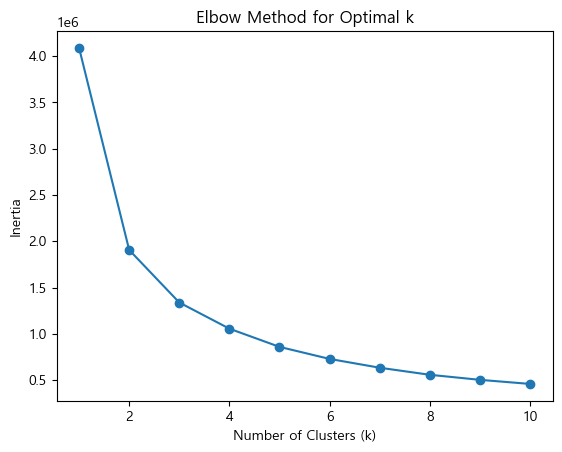

         Recency  Frequency  Monetary
Cluster                              
0           31.5       12.9       0.3
1          176.3       26.8       0.7
2          397.4        4.2       0.1
3           39.6       96.2       2.8


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 분석에 사용할 데이터 선택 (Recency, Frequency, Monetary)
# 로그 변환을 통해 데이터의 치우침(Skewness)을 완화해주면 더 정확합니다.
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

# 2. 스케일링 (표준화: 평균 0, 표준편차 1로 맞추기)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 3. 최적의 군집 수(K) 찾기 (Elbow Method)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# 엘보우 그래프 시각화 (포트폴리오에 넣기 아주 좋음!)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# 4. K-means 모델 학습 (K가 4라고 가정했을 때)
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 5. 군집별 특징 확인
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

print(cluster_summary)